In [48]:
import pandas as pd
import os
import seaborn as sns
from scipy.signal import periodogram
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
satellites = os.listdir('./data/dataframes/')
for selected_satellite in satellites:
    if 'csv' not in selected_satellite:
        continue
    print(f'Converting {selected_satellite} to parquet')
    selected_satellite = selected_satellite.split('.')[0]
    df = pd.read_csv(f'./data/dataframes/{selected_satellite}.csv', index_col='time', parse_dates=True)
    df.to_parquet(f'./data/dataframes/{selected_satellite}.parquet')

Converting S3A_RDAEFI.csv to parquet
Converting SWMB_RDBWFI.csv to parquet
Converting SWMC_RDCWFI.csv to parquet
Converting SWMA_RDAWFI.csv to parquet
Converting GFOC_RDCDFI.csv to parquet
Converting GFOD_RDDDFI.csv to parquet
Converting S3B_RDAEFI.csv to parquet


In [10]:
satellites = os.listdir('./data/dataframes/')
df = pd.read_csv(f'./data/dataframes/{satellites[6]}', index_col='time', parse_dates=True)

In [14]:
df.loc[df['res_std'] == 0, 'res_std'] = None

<Axes: ylabel='res_std'>

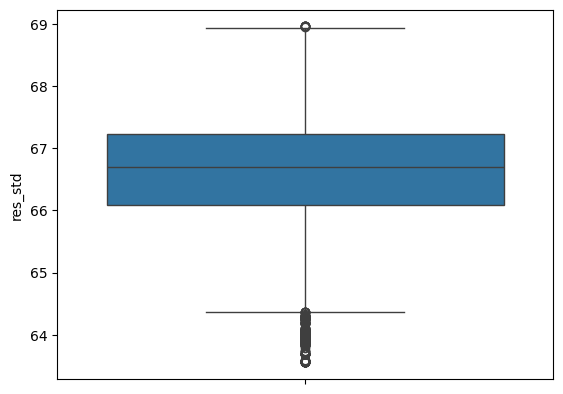

In [19]:
dfc = df[(df.index >= '2024-05-01') & (df.index < '2024-05-15')].copy()
sns.boxplot(dfc['res_std'])

In [22]:
dfc['orbital_decay'].mean(), dfc['orbital_decay'].median(), dfc['orbital_decay'].std()

(53.380975712062884, 45.18393716755366, 33.04859849644419)

In [24]:
dfc['res'].mean(), dfc['res'].median(), dfc['res'].std()

(0.0526776669986984, -1.5672241342253983, 66.5258414386105)

In [54]:
def filter_by_log_intervals(values):
    first_in_interval = {}
    
    for value in values:
        log_interval = int(np.floor(np.log10(value)))
        
        if log_interval not in first_in_interval:
            first_in_interval[log_interval] = value
    
    return list(first_in_interval.values())

Period of the two most prominent frequencies in the a [m]: [47 50] minutes


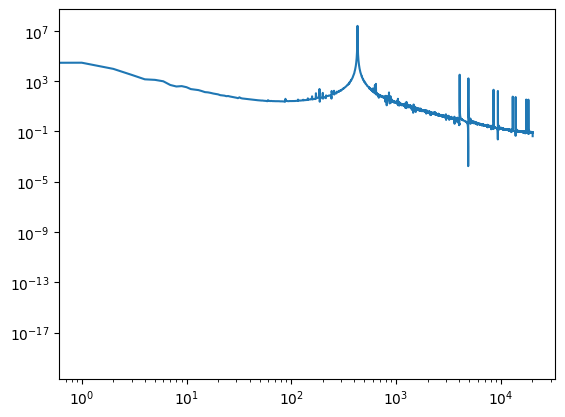

In [57]:
fs = (dfc.index.max() - dfc.index.min()) // pd.Timedelta("30s")
freqencies, spectrum = periodogram(
    dfc['a [m]'],
    fs=fs,
    window="boxcar",
    scaling='spectrum'
)

sorted_spectra_idx = np.argsort(spectrum)[::-1]
sorted_freqs = freqencies[sorted_spectra_idx]
sorted_freqs = sorted_freqs[sorted_freqs > 10]
periods = [round (fs / freq) for freq in sorted_freqs]
periods = list(dict.fromkeys(periods))
periods = np.array(filter_by_log_intervals(periods)[:2])

print(f"Period of the two most prominent frequencies in the a [m]: {periods // 2} minutes")

sns.lineplot(x=freqencies, y=spectrum)
plt.yscale('log')
plt.xscale('log')

Period of the two most prominent frequencies in the orbital_decay: [1680  117] minutes


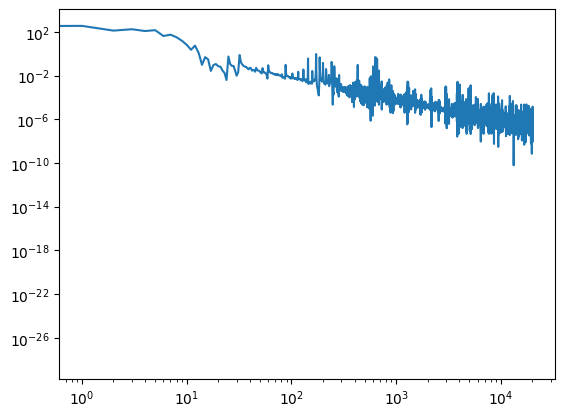

In [58]:
fs = (dfc.index.max() - dfc.index.min()) // pd.Timedelta("30s")
freqencies, spectrum = periodogram(
    dfc['orbital_decay'],
    fs=fs,
    window="boxcar",
    scaling='spectrum'
)

sorted_spectra_idx = np.argsort(spectrum)[::-1]
sorted_freqs = freqencies[sorted_spectra_idx]
sorted_freqs = sorted_freqs[sorted_freqs > 10]
periods = [round (fs / freq) for freq in sorted_freqs]
periods = list(dict.fromkeys(periods))
periods = np.array(filter_by_log_intervals(periods)[:2])

print(f"Period of the two most prominent frequencies in the orbital_decay: {periods // 2} minutes")

sns.lineplot(x=freqencies, y=spectrum)
plt.yscale('log')
plt.xscale('log')

1680 which is 28 hours coincides with 14 periods, the spectrum amplitude is quite low though. Other is orbital period, some low amplitude artefact still remaining after decomposing.

Period of the two most prominent frequencies in the residuals: [31  4] minutes


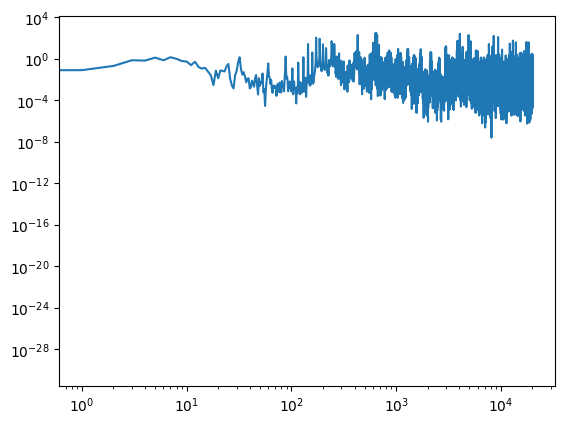

In [77]:
fs = (dfc.index.max() - dfc.index.min()) // pd.Timedelta("30s")
freqencies, spectrum = periodogram(
    dfc['res'],
    fs=fs,
    window="boxcar",
    scaling='spectrum'
)

sorted_spectra_idx = np.argsort(spectrum)[::-1]
sorted_freqs = freqencies[sorted_spectra_idx]
sorted_freqs = sorted_freqs[sorted_freqs > 0]
periods = [round (fs / freq) for freq in sorted_freqs]
periods = list(dict.fromkeys(periods))
periods = np.array(filter_by_log_intervals(periods)[:2])

print(f"Period of the two most prominent frequencies in the residuals: {periods // 2} minutes")

sns.lineplot(x=freqencies, y=spectrum)
plt.yscale('log') 
plt.xscale('log')